# Role of light polarization

Over time t, if t is sufficiently large, a molecule which rotates freely in space will have a transition dipole moment vector pointing in random directions, where each direction has an equal probability. It does not matter, whether the polarization of the incident light is linear or circular - one third will be exciting the rotating molecule. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [3]:
rng = np.random.default_rng(100)

In [3]:
# random orientations in 3D space
x_component = rng.normal(size=1000)
y_component = rng.normal(size=1000)
z_component = rng.normal(size=1000)
norm = 1/np.sqrt(x_component**2 + y_component**2 + z_component**2)
x_norm = x_component * norm
y_norm = y_component * norm
z_norm = z_component * norm
distances = np.sqrt(x_norm**2 + y_norm**2 + z_norm**2)

https://math.stackexchange.com/questions/1585975/how-to-generate-random-points-on-a-sphere

In [4]:
radian_to_z = np.arccos(z_norm)
angle_to_z = radian_to_z * 180/np.pi

https://www.youtube.com/watch?v=vH-DagcgJvE&t=561s

$I\propto\bracevert E^2\bracevert$ \
$\bracevert E \bracevert _{eff} = \bracevert E \bracevert cos(\theta)$ \
$I = I_0 * cos^2(\theta)$ \
The effective intensity $I$ is hence dependent on the angle $\theta$, which is the angle between the direction of the E-field and the transition dipole moment. If they are parallel, $cos^2(0) = 1 = max$ \
Here it is assumed that the light is linearily polarized in z-direction (E field). 

In [5]:
absorption_rate = np.cos(radian_to_z)**2

In [6]:
end_point_x = x_norm*absorption_rate
end_point_y = y_norm*absorption_rate
end_point_z = z_norm*absorption_rate

A molecule (orange) has random orientations (transition dipole moment), indicated by the blue dots. 

(-1.0, 1.0)

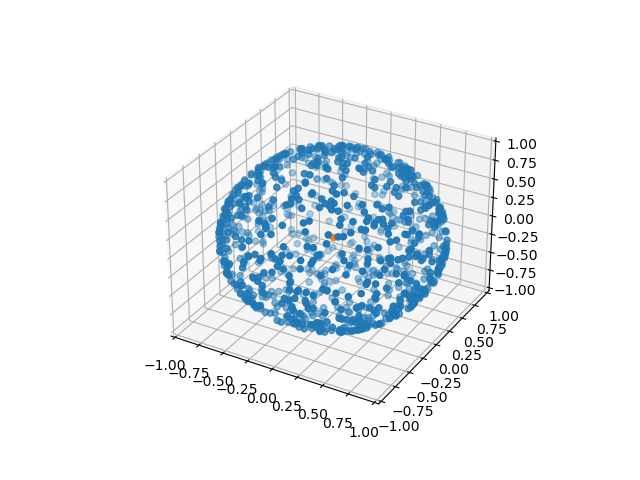

In [19]:
fig = plt.figure()
ax = plt.axes(projection="3d")
ax.scatter3D(x_norm, y_norm, z_norm)
ax.scatter3D(0, 0, 0, "red")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

## z-polarization
Linearily polarized light is used to excite the molecule. See above.
Each orientation corresponds to a certain strength of interaction with the polarized light. Note that the direction of light has to be within the x/y plane.

(-1.0, 1.0)

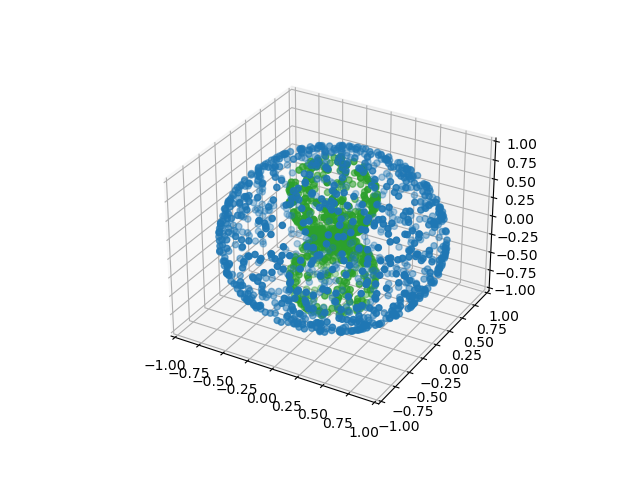

In [20]:
fig = plt.figure()
ax = plt.axes(projection="3d")
ax.scatter3D(x_norm, y_norm, z_norm)
ax.scatter3D(0, 0, 0, "red")
ax.scatter3D(end_point_x, end_point_y, end_point_z)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

The mean effective intensity of the linearily polarized light is 0.33 - meaning that 1/3 of the light that could potentially excite the molecule will actually excite it. Note that the light that could potentially excite the molecule assumes the molecule to be perfectly oriented (transition dipole moment in z-direction at all times). This does not mean that in this hypothetical case all the light is absorbed - it is just the optimum condition (highest excitation rate, 3 times larger than that of the random orientation). In most experimental conditions, the random orientation applies, meaning that measurements of extinction coefficients correspond to the absorbance of a randomly oriented molecule. If the molecule could be assumed to be perfectly oriented towards the incident light and one wants to apply the measured extinction coefficient to randomly oriented molecules, the extinction coefficient has to be divided by 3.

In [9]:
np.mean(absorption_rate)

0.3502916717389011

## z- and y-polarization

In [11]:
half = int(len(z_norm)/2)

In [12]:
z = z_norm[:half]
y = y_norm[half:]

In [13]:
radian_to_z = np.arccos(z)
radian_to_y = np.arccos(y)

In [14]:
absorption_rate_z = np.cos(radian_to_z)**2
absorption_rate_y = np.cos(radian_to_y)**2

The mean of the circular polarized light is 0.33

In [15]:
np.mean([absorption_rate_z, absorption_rate_y])

0.32858608543153944

In [16]:
z_end_point_x = x_norm[:half]*absorption_rate_z
z_end_point_y = y_norm[:half]*absorption_rate_z
z_end_point_z = z*absorption_rate_z

In [17]:
y_end_point_x = x_norm[half:]*absorption_rate_y
y_end_point_y = y*absorption_rate_y
y_end_point_z = z_norm[half:]*absorption_rate_y

Double linearily polairzed light is used to excite the molecule. 
Note that the direction of light has to be in x direction. 

(-1.0, 1.0)

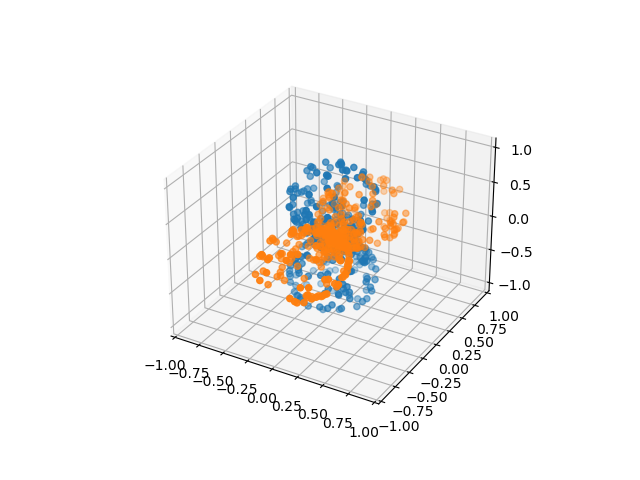

In [18]:
fig = plt.figure()
ax = plt.axes(projection="3d")
# ax.scatter3D(x_norm, y_norm, z_norm)
# ax.scatter3D(0, 0, 0, "red")
ax.scatter3D(z_end_point_x, z_end_point_y, z_end_point_z)
ax.scatter3D(y_end_point_x, y_end_point_y, y_end_point_z)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

## FRET Kappa squared

$\kappa^2=(\cos(\theta_{DA})-3\cos(\theta_D)\cos(\theta_A))^2$\
This comes from interaction energy of two dipoles (since the distance between the molecules is high relative to the dimensions of a molecule, see original Förster paper 1948 'Zwischenmolekulare Energiewanderung und Fluoreszenz', page 62).
Let's consider the joining vector of the donor and the acceptor to be equal to the y-axis. 

In [85]:
rng = np.random.default_rng(100)
# random orientations of donor
x_component_D = rng.normal(size=10000)
y_component_D = rng.normal(size=10000)
z_component_D = rng.normal(size=10000)
norm_D = 1/np.sqrt(x_component_D**2 + y_component_D**2 + z_component_D**2)
x_norm_D = x_component_D * norm_D
y_norm_D = y_component_D * norm_D
z_norm_D = z_component_D * norm_D

In [86]:
radian_to_y_D = np.arccos(y_norm_D)

In [87]:
rng = np.random.default_rng(10)
# random orientations of acceptor
x_component_A = rng.normal(size=10000)
y_component_A = rng.normal(size=10000)
z_component_A = rng.normal(size=10000)
norm_A = 1/np.sqrt(x_component_A**2 + y_component_A**2 + z_component_A**2)
x_norm_A = x_component_A * norm_A
y_norm_A = y_component_A * norm_A
z_norm_A = z_component_A * norm_A

In [88]:
radian_to_y_A = np.arccos(y_norm_A)

In [89]:
matrix_A = np.vstack((x_norm_A, y_norm_A, z_norm_A)).T
matrix_D = np.vstack((x_norm_D, y_norm_D, z_norm_D)).T
vector_lengths_A = np.linalg.norm(matrix_A, axis=1)  # the 2-norm 
# see https://en.wikipedia.org/wiki/Norm_(mathematics) --> euclidean norm
vector_lengths_D = np.linalg.norm(matrix_D, axis=1)

In [90]:
dot_product = np.dot(matrix_A, np.transpose(matrix_D))
radians = np.arccos(np.diagonal(dot_product) / (vector_lengths_A*vector_lengths_D))

In [93]:
def kappa_sq(theta_DA, theta_D, theta_A):
    
    return (np.cos(theta_DA) - 3*np.cos(theta_D)*np.cos(theta_A))**2 

In [94]:
random_kappa_sq = kappa_sq(radians, radian_to_y_D, radian_to_y_A)

In [96]:
np.mean(random_kappa_sq)

0.6694204324777328

There is a difference if the dipole moments are parallel head-to-tail or just parallel, where the first case maximizes the FRET efficiency. This is the reason why the angle between the two transition dipoles is not sufficient, since it would be equal in the two cases.
Note that the dipole of the donor is the emission dipole, whilst the dipole of the acceptor is the absorption dipole.

In [97]:
kappa_sq(0, 0, 0)

4.0

In [100]:
kappa_sq(0, 90*np.pi/180, 90*np.pi/180)

1.0

In [108]:
round(kappa_sq(np.pi/2, 0, np.pi/2), 30)

0.0